In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Dados em painel são dados que acompanham **várias unidades ao longo do tempo.**

eles acompanham **dados transversais** como indivíduos, países, estados, lojas, etc. Também acompanham **dados de dimensão temporal** como anos, meses, dias, minutos

Exemplo da análise:
    - **Óbitos infantis de várias UFS ao longo dos anos.**


Diferença entre dados transversais e longitudinais são similares a diferença entre uma fotografia e um filme.

- Dados transversais são aqueles que representam apenas um único período de tempo, uma fotografia representando um instante.

- Dados longitudinais são aqueles que representam uma sequência de fotografias ao longo de um período de tempo, de uma profundidade de solo, ao longo da margem de um rio, ou seja, representa uma continuidade para aquela unidade observacional e uma possível correlação estatística para a mesma, como um filme discorrendo várias fotografias ao longo do tempo.


Dados em paineis são um exemplo de dados longitudinais, porém deles podem ser vistos dados em recortes transversais.

In [2]:
df = pd.read_csv('../data/mortalidade.csv')

df.head()

,Indicador,Ano,UF,Numerador - Obitos em menores de 5 anos estimados,Denominador - Nascidos vivos estimados,Fator
0,MRT.1.05,2000,11,1404.0,35005.0,1000
1,MRT.1.05,2000,12,819.0,20249.0,1000
2,MRT.1.05,2000,13,3899.0,88258.0,1000
3,MRT.1.05,2000,14,323.0,11185.0,1000
4,MRT.1.05,2000,15,6229.0,174996.0,1000


Neste tipo de estrutura, cada unidade aparece mais de uma vez, porque é observada em diferentes momentos do tempo.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 675 entries, 0 to 674
Data columns (total 6 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Indicador                                          675 non-null    str    
 1   Ano                                                675 non-null    int64  
 2   UF                                                 675 non-null    int64  
 3   Numerador - Obitos em menores de 5 anos estimados  675 non-null    float64
 4   Denominador - Nascidos vivos estimados             675 non-null    float64
 5   Fator                                              675 non-null    int64  
dtypes: float64(2), int64(3), str(1)
memory usage: 31.8 KB


Para melhor compreensão dos dados, irei transformar o código das UFs em suas respectivas siglas.

Os dados são provenientes deste site: https://sistemasweb.agricultura.gov.br/manuais/Manual_PGA_WS/322CodigoIBGESigladaUnidadeFeder.html

In [4]:
unidades_federativas = {
    11: 'RO',
    12: 'AC',
    13: 'AM',
    14: 'RR',
    15: 'PA',
    16: 'AP',
    17: 'TO',
    21: 'MA',
    22: 'PI',
    23: 'CE',
    24: 'RN',
    25: 'PB',
    26: 'PE',
    27: 'AL',
    28: 'SE',
    29: 'BA',
    31: 'MG',
    32: 'ES',
    33: 'RJ',
    35: 'SP',
    41: 'PR',
    42: 'SC',
    43: 'RS',
    50: 'MS',
    51: 'MT',
    52: 'GO',
    53: 'DF'
}

df['UF'] = df['UF'].replace(unidades_federativas)
df

,Indicador,Ano,UF,Numerador - Obitos em menores de 5 anos estimados,Denominador - Nascidos vivos estimados,Fator
0,MRT.1.05,2000,RO,1404.0,35005.0,1000
1,MRT.1.05,2000,AC,819.0,20249.0,1000
2,MRT.1.05,2000,AM,3899.0,88258.0,1000
3,MRT.1.05,2000,RR,323.0,11185.0,1000
4,MRT.1.05,2000,PA,6229.0,174996.0,1000
...,...,...,...,...,...,...
670,MRT.1.05,2024,RS,0.0,0.0,1000
671,MRT.1.05,2024,MS,0.0,0.0,1000
672,MRT.1.05,2024,MT,0.0,0.0,1000
673,MRT.1.05,2024,GO,0.0,0.0,1000


Ao se tratar de dados em painel, é de interesse ter os índices devidamente ordenados tanto pela unidade observacional quanto pela dimensão temporal. No exemplo da análise, o dataset deve ser ordenado por UF por ano.

In [5]:
df = df.sort_values(['UF', 'Ano'])

df

,Indicador,Ano,UF,Numerador - Obitos em menores de 5 anos estimados,Denominador - Nascidos vivos estimados,Fator
1,MRT.1.05,2000,AC,819.0,20249.0,1000
28,MRT.1.05,2001,AC,621.0,19647.0,1000
55,MRT.1.05,2002,AC,619.0,20175.0,1000
82,MRT.1.05,2003,AC,536.0,19381.0,1000
109,MRT.1.05,2004,AC,584.0,19095.0,1000
...,...,...,...,...,...,...
546,MRT.1.05,2020,TO,320.0,23974.0,1000
573,MRT.1.05,2021,TO,371.0,23946.0,1000
600,MRT.1.05,2022,TO,354.0,22689.0,1000
627,MRT.1.05,2023,TO,345.0,23404.0,1000


# Visualização de dados em painel

É necessário pensar a estrutura de correlação das unidades aos longo do tempo, tendo em vista que é a mesma unidade observada em diversos períodos.

**O melhor gráfico para essa visualização se trata do gráfico de linha**

Isso se dá devido a estrutura longitudinal do dado.

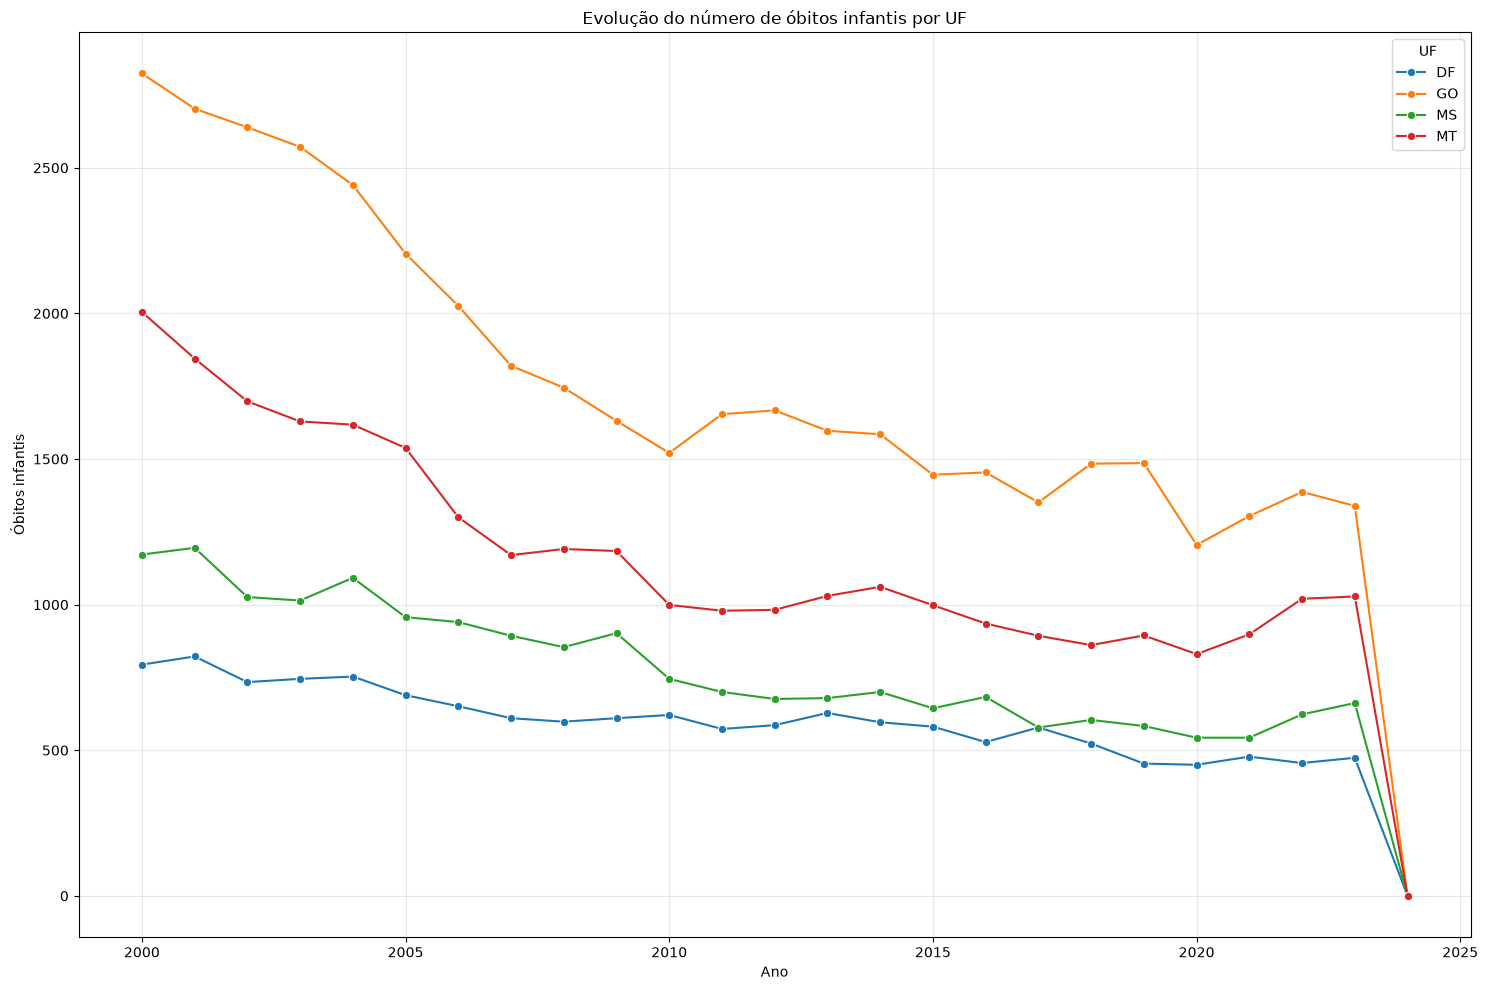

In [6]:
# Definindo um DF apenas da Região Centro-Oeste para melhor visualização dos dados.

centro_oeste = ['MT', 'MS', 'GO', 'DF']
filtro = df['UF'].isin(centro_oeste)
df_centro_oeste = df[filtro]

# Gráfico de linha
plt.figure(figsize=(15,10))

sns.lineplot(
    data=df_centro_oeste,
    x="Ano",
    y="Numerador - Obitos em menores de 5 anos estimados",
    hue= "UF",
    marker="o"
)

plt.title("Evolução do número de óbitos infantis por UF")
plt.xlabel("Ano")
plt.ylabel("Óbitos infantis")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Outra forma de visualização dos dados em painel é através do **mapa de calor**, uma maneira mais intuitiva e visual de analisar um valor númerico para cada uma das unidades pelo tempo.

Para essa visualização, é utilizada uma tabela em formato matricial do pandas, a estrutura pivot.

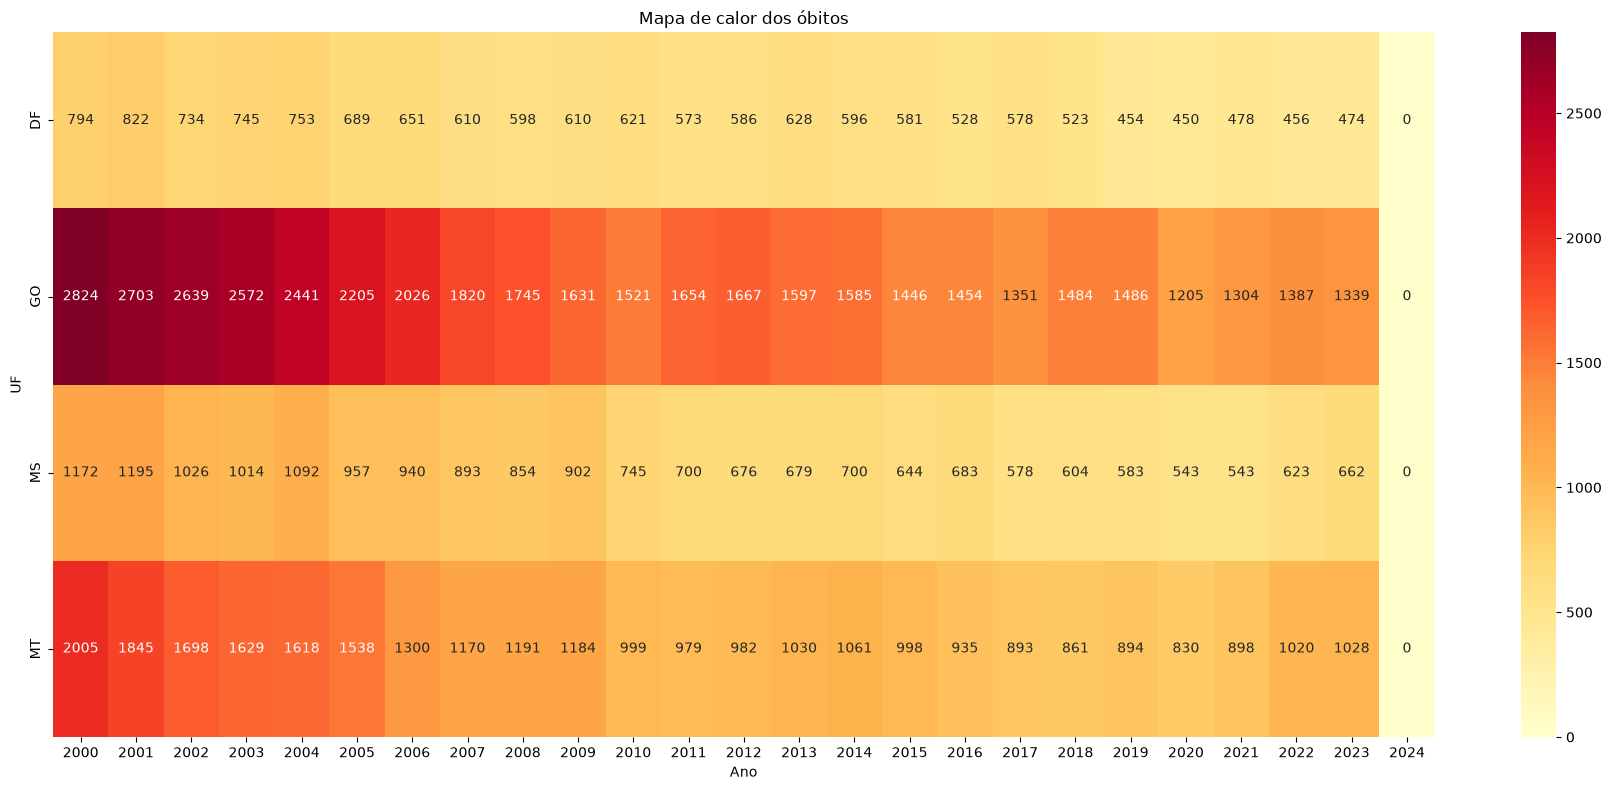

In [7]:
# Mapa de calor

tabela = df_centro_oeste.pivot(index="UF", columns="Ano", values="Numerador - Obitos em menores de 5 anos estimados")

plt.figure(figsize=(18, 8))

sns.heatmap(
    tabela,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title("Mapa de calor dos óbitos")
plt.xlabel("Ano")
plt.ylabel("UF")

plt.tight_layout()
plt.show()

# Identificando a estrutura de painel

Neste exemplo:  
    - **UF** representa a unidade observada.    
    - **Ano** representa o tempo.   
    - **Numerador** representa a variável observada.


Transformando a estrutura em painel.

In [8]:
df_painel = df.set_index(['UF', 'Ano'])
df_painel

Indicador  Numerador - Obitos em menores de 5 anos estimados  \
UF Ano                                                                 
AC 2000  MRT.1.05                                              819.0   
   2001  MRT.1.05                                              621.0   
   2002  MRT.1.05                                              619.0   
   2003  MRT.1.05                                              536.0   
   2004  MRT.1.05                                              584.0   
...           ...                                                ...   
TO 2020  MRT.1.05                                              320.0   
   2021  MRT.1.05                                              371.0   
   2022  MRT.1.05                                              354.0   
   2023  MRT.1.05                                              345.0   
   2024  MRT.1.05                                                0.0   

         Denominador - Nascidos vivos estimados  Fator  
UF Ano                                                  
AC 2000                                 20249.0   1000  
   2001                                 19647.0   1000  
   2002                                 20175.0   1000  
   2003                                 19381.0   1000  
   2004                                 19095.0   1000  
...                                         ...    ...  
TO 2020                                 23974.0   1000  
   2021                                 23946.0   1000  
   2022                                 22689.0   1000  
   2023                                 23404.0   1000  
   2024                                     0.0   1000  

[675 rows x 4 columns]

Agrupando dados por UF

In [9]:
df.groupby('UF')['Numerador - Obitos em menores de 5 anos estimados'].mean()

UF
AC     424.28
AL    1539.12
AM    2014.72
AP     413.96
BA    5753.64
CE    2965.40
DF     581.28
ES     801.64
GO    1723.44
MA    3562.44
MG    4888.00
MS     760.32
MT    1143.44
PA    3676.44
PB    1469.60
PE    3285.40
PI    1331.88
PR    2226.64
RJ    3607.68
RN    1147.80
RO     632.20
RR     269.12
RS    1905.84
SC    1156.52
SE     893.16
SP    8404.08
TO     621.64
Name: Numerador - Obitos em menores de 5 anos estimados, dtype: float64

Agrupando dados por Ano

In [10]:
df.groupby('Ano')['Numerador - Obitos em menores de 5 anos estimados'].mean()

Ano
2000    4246.333333
2001    3864.851852
2002    3586.592593
2003    3367.185185
2004    3069.111111
2005    2835.370370
2006    2581.888889
2007    2368.333333
2008    2223.481481
2009    2105.888889
2010    1923.000000
2011    1882.703704
2012    1823.740741
2013    1771.888889
2014    1722.407407
2015    1637.592593
2016    1607.740741
2017    1587.851852
2018    1578.481481
2019    1551.148148
2020    1360.888889
2021    1391.074074
2022    1448.074074
2023    1427.037037
2024       0.000000
Name: Numerador - Obitos em menores de 5 anos estimados, dtype: float64

Tabela em formato matricial

In [11]:
tabela = df.pivot(index='Ano', columns='UF', values='Numerador - Obitos em menores de 5 anos estimados')
tabela

UF,AC,AL,AM,AP,BA,CE,DF,ES,GO,MA,...,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO
Ano,,,,,,,,,,,,,,,,,,,,,
2000,819.0,4256.0,3899.0,587.0,13657.0,6963.0,794.0,1302.0,2824.0,7681.0,...,4115.0,5788.0,2894.0,1404.0,323.0,3099.0,1721.0,2087.0,13692.0,1409.0
2001,621.0,4203.0,3582.0,622.0,12049.0,6065.0,822.0,1135.0,2703.0,7773.0,...,3389.0,5167.0,2722.0,1315.0,279.0,2967.0,1622.0,2079.0,12000.0,1303.0
2002,619.0,3508.0,3322.0,578.0,10846.0,6033.0,734.0,1089.0,2639.0,7757.0,...,3349.0,4890.0,2502.0,1172.0,207.0,2934.0,1550.0,1736.0,11242.0,1193.0
2003,536.0,2958.0,3041.0,518.0,10250.0,5816.0,745.0,996.0,2572.0,6812.0,...,2973.0,4822.0,2054.0,1075.0,274.0,2771.0,1430.0,1489.0,10855.0,1052.0
2004,584.0,2284.0,2640.0,505.0,9261.0,4943.0,753.0,959.0,2441.0,5818.0,...,2974.0,4605.0,1892.0,1013.0,301.0,2666.0,1355.0,1302.0,10471.0,984.0
2005,627.0,2255.0,2540.0,448.0,8394.0,4094.0,689.0,961.0,2205.0,5728.0,...,2727.0,4201.0,1649.0,858.0,274.0,2363.0,1260.0,1257.0,9790.0,905.0
2006,503.0,1850.0,2445.0,480.0,7563.0,3779.0,651.0,932.0,2026.0,4732.0,...,2511.0,3920.0,1320.0,793.0,292.0,2180.0,1264.0,1132.0,9428.0,843.0
2007,547.0,1768.0,2116.0,472.0,6763.0,3290.0,610.0,871.0,1820.0,4319.0,...,2319.0,3791.0,1281.0,664.0,240.0,1994.0,1212.0,905.0,9127.0,764.0
2008,468.0,1540.0,2118.0,492.0,6019.0,3001.0,598.0,876.0,1745.0,3763.0,...,2327.0,3651.0,1186.0,637.0,262.0,1990.0,1194.0,897.0,8830.0,678.0


Taxa de mortalidade na infância.

O resultado da operação mostra a quantidade de óbitos a cada 1000 nascidos vivos.

In [12]:
df['Mortalidade'] = (df['Numerador - Obitos em menores de 5 anos estimados'] / df['Denominador - Nascidos vivos estimados'])*df['Fator']

df

,Indicador,Ano,UF,Numerador - Obitos em menores de 5 anos estimados,Denominador - Nascidos vivos estimados,Fator,Mortalidade
1,MRT.1.05,2000,AC,819.0,20249.0,1000,40.446442
28,MRT.1.05,2001,AC,621.0,19647.0,1000,31.607879
55,MRT.1.05,2002,AC,619.0,20175.0,1000,30.681537
82,MRT.1.05,2003,AC,536.0,19381.0,1000,27.655952
109,MRT.1.05,2004,AC,584.0,19095.0,1000,30.583922
...,...,...,...,...,...,...,...
546,MRT.1.05,2020,TO,320.0,23974.0,1000,13.347793
573,MRT.1.05,2021,TO,371.0,23946.0,1000,15.493193
600,MRT.1.05,2022,TO,354.0,22689.0,1000,15.602274
627,MRT.1.05,2023,TO,345.0,23404.0,1000,14.741070


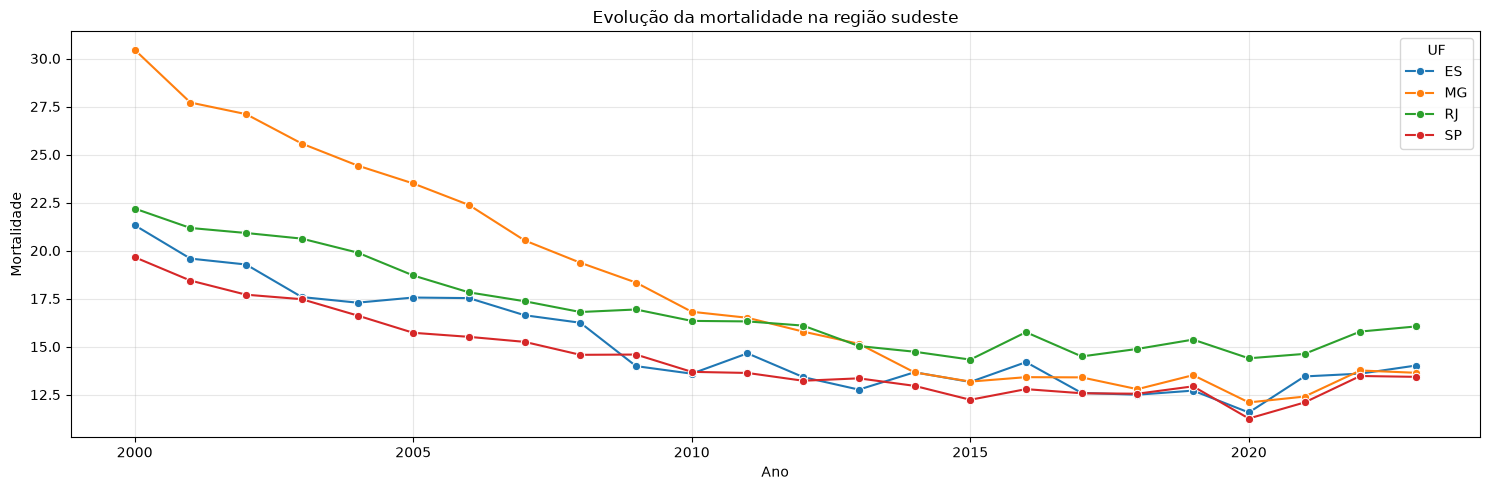

In [13]:

# Definindo um DF com os estados da região sudeste para criar uma melhor visualização

sudeste = ['ES', 'SP', 'MG', 'RJ']
filtro = df['UF'].isin(sudeste)

df_sudeste = df[filtro]
df_sudeste.dtypes

# Gráfico de linha
plt.figure(figsize=(15, 5))

sns.lineplot(
    data=df_sudeste,
    x="Ano",
    y="Mortalidade",
    hue="UF",
    marker="o"
)

plt.title("Evolução da mortalidade na região sudeste")
plt.xlabel("Ano"),
plt.ylabel("Mortalidade")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

A melhor forma de se estruturar um dado em painel é utilizando **Multindex** do pandas baseado na unidade e no tempo das variáveis observadas

In [14]:
painel_indexado = df.set_index(['UF', 'Ano'])
painel_indexado

Indicador  Numerador - Obitos em menores de 5 anos estimados  \
UF Ano                                                                 
AC 2000  MRT.1.05                                              819.0   
   2001  MRT.1.05                                              621.0   
   2002  MRT.1.05                                              619.0   
   2003  MRT.1.05                                              536.0   
   2004  MRT.1.05                                              584.0   
...           ...                                                ...   
TO 2020  MRT.1.05                                              320.0   
   2021  MRT.1.05                                              371.0   
   2022  MRT.1.05                                              354.0   
   2023  MRT.1.05                                              345.0   
   2024  MRT.1.05                                                0.0   

         Denominador - Nascidos vivos estimados  Fator  Mortalidade  
UF Ano                                                               
AC 2000                                 20249.0   1000    40.446442  
   2001                                 19647.0   1000    31.607879  
   2002                                 20175.0   1000    30.681537  
   2003                                 19381.0   1000    27.655952  
   2004                                 19095.0   1000    30.583922  
...                                         ...    ...          ...  
TO 2020                                 23974.0   1000    13.347793  
   2021                                 23946.0   1000    15.493193  
   2022                                 22689.0   1000    15.602274  
   2023                                 23404.0   1000    14.741070  
   2024                                     0.0   1000          NaN  

[675 rows x 5 columns]

Com o painel estruturado, se torna mais simples criar recortes através da função **loc**

In [15]:
# Dados de GO
painel_indexado.loc['GO']

,Indicador,Numerador - Obitos em menores de 5 anos estimados,Denominador - Nascidos vivos estimados,Fator,Mortalidade
Ano,,,,,
2000,MRT.1.05,2824.0,98329.0,1000,28.719910
2001,MRT.1.05,2703.0,99439.0,1000,27.182494
2002,MRT.1.05,2639.0,99592.0,1000,26.498112
2003,MRT.1.05,2572.0,98897.0,1000,26.006856
2004,MRT.1.05,2441.0,96468.0,1000,25.303728
2005,MRT.1.05,2205.0,97325.0,1000,22.656049
2006,MRT.1.05,2026.0,94309.0,1000,21.482573
2007,MRT.1.05,1820.0,91020.0,1000,19.995605
2008,MRT.1.05,1745.0,92605.0,1000,18.843475


In [16]:
# Dados de GO em 2006

painel_indexado.loc[('GO', 2006)]

Indicador                                             MRT.1.05
Numerador - Obitos em menores de 5 anos estimados       2026.0
Denominador - Nascidos vivos estimados                 94309.0
Fator                                                     1000
Mortalidade                                          21.482573
Name: (GO, 2006), dtype: object

In [17]:
# Média de mortalidade por UF

painel_indexado.groupby("UF")[['Mortalidade']].mean()

,Mortalidade
UF,
AC,24.678388
AL,25.880783
AM,25.879897
AP,26.627353
BA,25.576331
CE,21.700887
DF,13.778514
ES,15.120421
GO,18.708014


In [18]:
# Média de mortalidade por ano

painel_indexado.groupby("Ano")[['Mortalidade']].mean()

,Mortalidade
Ano,
2000,35.478952
2001,34.398309
2002,32.261283
2003,30.152355
2004,28.392710
2005,26.022344
2006,24.295229
2007,22.999055
2008,21.432776


Transformando em formato matricial com pivot

In [19]:
painel_pivot = painel_indexado.reset_index().pivot(index="Ano", columns="UF", values="Mortalidade")
painel_pivot

UF,AC,AL,AM,AP,BA,CE,DF,ES,GO,MA,...,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO
Ano,,,,,,,,,,,,,,,,,,,,,
2000,40.446442,57.422724,44.177298,33.556280,47.306472,41.150537,16.472004,21.321543,28.719910,47.292721,...,22.203876,22.189593,46.723389,40.108556,28.877962,17.301251,18.030194,47.064926,19.657755,47.107991
2001,31.607879,56.866459,43.367718,36.114498,44.563702,37.464636,17.452970,19.584836,27.182494,55.145259,...,19.965477,21.178486,47.263509,38.594741,25.407522,18.261046,18.449429,51.122532,18.441395,45.120853
2002,30.681537,49.487212,40.619192,34.470420,40.298130,38.519739,15.955481,19.276383,26.498112,52.652299,...,20.049210,20.917191,43.680930,37.501600,20.204978,18.756233,18.007552,44.991577,17.705303,41.412108
2003,27.655952,42.572790,38.637952,30.065587,38.751777,38.905352,16.090365,17.582573,26.006856,43.263704,...,18.959734,20.624201,36.981689,34.932086,23.757912,18.490468,16.983171,38.005054,17.470644,36.167360
2004,30.583922,35.137380,33.860479,31.387905,36.025487,33.939852,16.442125,17.289560,25.303728,38.672968,...,18.827432,19.897853,34.411262,33.910220,27.338783,17.235472,15.532044,34.939888,16.621347,35.292852
2005,31.861375,34.083008,31.053243,28.430004,33.393936,27.354242,14.938965,17.557001,22.656049,37.344182,...,17.097393,18.706112,29.178094,28.401192,25.119179,15.821047,14.461316,32.666320,15.721907,31.340906
2006,26.416680,29.352034,29.792730,29.089146,31.511187,26.002353,14.354067,17.527693,21.482573,31.872188,...,16.098940,17.827014,24.548548,27.537591,27.180490,15.282802,14.800763,29.673902,15.510354,29.514740
2007,29.164001,28.738154,25.658126,30.301085,28.532253,23.072985,13.771928,16.635789,19.995605,30.169463,...,15.577349,17.364499,24.861235,23.637464,22.474014,14.856096,14.663182,24.731506,15.249562,28.627098
2008,24.612148,24.792324,25.474489,29.176303,25.696197,21.350313,13.477879,16.244483,18.843475,26.959063,...,15.235239,16.803203,22.465100,23.077202,23.388681,14.582280,14.022972,24.088297,14.575094,24.916394


Ao tratar a tabela dentro da estrutura pivot, há algumas funções especiais do pandas que podem auxiliar nas análises de dados longitudinais

In [20]:
# Diferença entre períodos.

painel_pivot.diff()

UF,AC,AL,AM,AP,BA,CE,DF,ES,GO,MA,...,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO
Ano,,,,,,,,,,,,,,,,,,,,,
2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001,-8.838563,-0.556264,-0.809581,2.558218,-2.742770,-3.685901,0.980967,-1.736707,-1.537416,7.852538,...,-2.238399,-1.011107,0.540120,-1.513815,-3.470439,0.959796,0.419235,4.057606,-1.216360,-1.987137
2002,-0.926343,-7.379247,-2.748526,-1.644078,-4.265571,1.055103,-1.497489,-0.308453,-0.684381,-2.492960,...,0.083733,-0.261295,-3.582579,-1.093141,-5.202544,0.495187,-0.441877,-6.130955,-0.736092,-3.708745
2003,-3.025585,-6.914422,-1.981240,-4.404833,-1.546353,0.385613,0.134884,-1.693811,-0.491257,-9.388595,...,-1.089476,-0.292990,-6.699241,-2.569514,3.552934,-0.265765,-1.024380,-6.986523,-0.234660,-5.244748
2004,2.927971,-7.435409,-4.777472,1.322318,-2.726289,-4.965500,0.351760,-0.293013,-0.703128,-4.590736,...,-0.132302,-0.726347,-2.570427,-1.021866,3.580871,-1.254996,-1.451127,-3.065165,-0.849296,-0.874508
2005,1.277453,-1.054372,-2.807237,-2.957901,-2.631551,-6.585610,-1.503160,0.267441,-2.647678,-1.328786,...,-1.730039,-1.191741,-5.233168,-5.509028,-2.219604,-1.414424,-1.070728,-2.273568,-0.899440,-3.951946
2006,-5.444695,-4.730974,-1.260513,0.659142,-1.882749,-1.351889,-0.584898,-0.029308,-1.173476,-5.471994,...,-0.998453,-0.879098,-4.629546,-0.863601,2.061311,-0.538245,0.339447,-2.992419,-0.211552,-1.826166
2007,2.747321,-0.613880,-4.134604,1.211939,-2.978934,-2.929368,-0.582139,-0.891904,-1.486968,-1.702725,...,-0.521591,-0.462516,0.312687,-3.900127,-4.706475,-0.426706,-0.137581,-4.942396,-0.260793,-0.887642
2008,-4.551853,-3.945830,-0.183637,-1.124782,-2.836057,-1.722672,-0.294049,-0.391306,-1.152130,-3.210400,...,-0.342110,-0.561295,-2.396136,-0.560262,0.914666,-0.273816,-0.640210,-0.643209,-0.674468,-3.710704


In [21]:
# Crescimento percentual entre os períodos
# (também chamado de retorno)

painel_pivot.pct_change()

UF,AC,AL,AM,AP,BA,CE,DF,ES,GO,MA,...,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO
Ano,,,,,,,,,,,,,,,,,,,,,
2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001,-0.218525,-0.009687,-0.018326,0.076237,-0.057979,-0.089571,0.059554,-0.081453,-0.053531,0.166041,...,-0.100811,-0.045567,0.011560,-0.037743,-0.120176,0.055476,0.023252,0.086213,-0.061877,-0.042183
2002,-0.029307,-0.129764,-0.063377,-0.045524,-0.095719,0.028163,-0.085801,-0.015750,-0.025177,-0.045207,...,0.004194,-0.012338,-0.075800,-0.028324,-0.204764,0.027117,-0.023951,-0.119927,-0.039915,-0.082196
2003,-0.098613,-0.139721,-0.048776,-0.127786,-0.038373,0.010011,0.008454,-0.087870,-0.018539,-0.178313,...,-0.054340,-0.014007,-0.153368,-0.068517,0.175844,-0.014169,-0.056886,-0.155285,-0.013254,-0.126648
2004,0.105871,-0.174652,-0.123647,0.043981,-0.070353,-0.127630,0.021862,-0.016665,-0.027036,-0.106111,...,-0.006978,-0.035218,-0.069505,-0.029253,0.150723,-0.067873,-0.085445,-0.080652,-0.048613,-0.024179
2005,0.041769,-0.030007,-0.082906,-0.094237,-0.073047,-0.194038,-0.091421,0.015468,-0.104636,-0.034360,...,-0.091889,-0.059893,-0.152077,-0.162459,-0.081189,-0.082065,-0.068937,-0.065071,-0.054114,-0.111976
2006,-0.170887,-0.138807,-0.040592,0.023185,-0.056380,-0.049422,-0.039153,-0.001669,-0.051795,-0.146529,...,-0.058398,-0.046995,-0.158665,-0.030407,0.082061,-0.034021,0.023473,-0.091606,-0.013456,-0.058268
2007,0.103999,-0.020914,-0.138779,0.041663,-0.094536,-0.112658,-0.040556,-0.050885,-0.069217,-0.053424,...,-0.032399,-0.025945,0.012737,-0.141629,-0.173156,-0.027921,-0.009296,-0.166557,-0.016814,-0.030075
2008,-0.156078,-0.137303,-0.007157,-0.037120,-0.099398,-0.074662,-0.021351,-0.023522,-0.057619,-0.106412,...,-0.021962,-0.032324,-0.096380,-0.023702,0.040699,-0.018431,-0.043661,-0.026008,-0.044229,-0.129622
